In [74]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

# === Funções auxiliares ===
def black_scholes_price_deribit(S_real, K, T, sigma, r, option_type="call"):
    F = np.exp(r * T)
    K_normalized = K / S_real
    d1 = (np.log(F / K_normalized) + 0.5 * sigma**2 * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    discount_factor = np.exp(-r * T)

    if option_type == "call":
        price_perc = discount_factor * (F * norm.cdf(d1) - K_normalized * norm.cdf(d2))
    elif option_type == "put":
        price_perc = discount_factor * (K_normalized * norm.cdf(-d2) - F * norm.cdf(-d1))
    else:
        raise ValueError("option_type deve ser 'call' ou 'put'")
    return price_perc * S_real

def black_scholes_delta_deribit(S_real, K, T, sigma, r, option_type="call"):
    F = np.exp(r * T)
    K_normalized = K / S_real
    d1 = (np.log(F / K_normalized) + 0.5 * sigma**2 * T) / (sigma * np.sqrt(T))
    discount_factor = np.exp(-r * T)

    if option_type == "call":
        delta = discount_factor * norm.cdf(d1)
    elif option_type == "put":
        delta = discount_factor * (norm.cdf(d1) - 1)
    else:
        raise ValueError("option_type deve ser 'call' ou 'put'")
    return delta

# === Função principal ===
def simulate_short_strangle(
    S0,
    DTE,
    iv,
    vol_real,
    strike_put,
    strike_call,
    delta_hedge_range=0.1,
    save_csv=True,
    fee_futures=0.0005,
    fee_options=0.0003
):
    r = 0.05
    steps_per_day = 24
    n_steps = DTE * steps_per_day
    dt = 1 / (365 * steps_per_day)

    np.random.seed(42)
    price_path = [S0]
    for _ in range(n_steps):
        S_t = price_path[-1]
        dS = S_t * (vol_real * np.random.normal() * np.sqrt(dt))
        price_path.append(S_t + dS)

    call_price_0 = black_scholes_price_deribit(S0, strike_call, DTE/365, iv, r, "call")
    put_price_0 = black_scholes_price_deribit(S0, strike_put, DTE/365, iv, r, "put")
    total_premium_received = call_price_0 + put_price_0

    btc_position = 0
    price_entry = None

    realized_pnl_futures = 0.0
    total_futures_fees = 0.0
    hedge_count = 0
    hedge_volume_usd = 0.0

    logs = []

    for t in range(n_steps + 1):
        S_t = price_path[t]
        T_remain = max(DTE/365 - t * dt, 1e-6)

        call_price_t = black_scholes_price_deribit(S_t, strike_call, T_remain, iv, r, "call")
        put_price_t = black_scholes_price_deribit(S_t, strike_put, T_remain, iv, r, "put")

        delta_call = black_scholes_delta_deribit(S_t, strike_call, T_remain, iv, r, "call")
        delta_put = black_scholes_delta_deribit(S_t, strike_put, T_remain, iv, r, "put")

        delta_options = -(delta_call + delta_put)

        delta_total_before_hedge = delta_options + btc_position

        if abs(delta_total_before_hedge) > delta_hedge_range:
            delta_adjustment = -delta_total_before_hedge
            notional = abs(delta_adjustment) * S_t
            fee_paid = notional * fee_futures

            if btc_position == 0:
                btc_position += delta_adjustment
                price_entry = S_t
            elif np.sign(btc_position) == np.sign(delta_adjustment):
                # Mesma direção: ajuste preço médio
                new_position = btc_position + delta_adjustment
                price_entry = (price_entry * abs(btc_position) + S_t * abs(delta_adjustment)) / abs(new_position)
                btc_position = new_position
            else:
                # Direção oposta: realiza parcialmente
                close_size = min(abs(delta_adjustment), abs(btc_position))
                realized_pnl_futures += close_size * (S_t - price_entry) * np.sign(btc_position)

                if abs(delta_adjustment) > abs(btc_position):
                    # Fechou tudo e abriu posição nova
                    open_size = abs(delta_adjustment) - abs(btc_position)
                    btc_position = np.sign(delta_adjustment) * open_size
                    price_entry = S_t
                else:
                    # Apenas reduziu posição
                    btc_position += delta_adjustment
                    if btc_position == 0:
                        price_entry = None

            total_futures_fees += fee_paid
            hedge_count += 1
            hedge_volume_usd += notional

        delta_total_after_hedge = delta_options + btc_position

        # UPL
        upl = btc_position * (S_t - price_entry) if btc_position != 0 else 0

        # PnL opções
        option_mtm = (call_price_0 + put_price_0) - (call_price_t + put_price_t)

        # Total PnL
        total_pnl_before_fee = realized_pnl_futures + upl + option_mtm

        logs.append({
            "Hour": t,
            "BTC_Price": S_t,
            "Delta_Options": delta_options,
            "Delta_Futures": btc_position,
            "Delta_Total": delta_total_after_hedge,
            "Put_Price": put_price_t,
            "Call_Price": call_price_t,
            "Option_MTM": option_mtm,
            "RPL_Futures": realized_pnl_futures,
            "UPL_Futures": upl,
            "Total_PNL_BeforeOptionFee": total_pnl_before_fee
        })

    df = pd.DataFrame(logs)

    # Aplica taxa de opções no final
    option_fees = (call_price_0 + put_price_0) * fee_options
    df["Total_PNL"] = df["Total_PNL_BeforeOptionFee"] - option_fees

    # Estatísticas
    pnl_final = df["Total_PNL"].iloc[-1]
    returns = df["Total_PNL"].diff().dropna()
    sharpe = returns.mean() / returns.std() * np.sqrt(steps_per_day * 365) if returns.std() > 0 else np.nan
    running_max = df["Total_PNL"].cummax()
    drawdown = (running_max - df["Total_PNL"]).max()

    print("\n==== RESUMO FINAL ====")
    print(f"Lucro líquido final: {pnl_final:.2f} USD")
    print(f"Sharpe Ratio: {sharpe:.2f}")
    print(f"Máximo Drawdown: {drawdown:.2f} USD")
    print(f"Número de hedges realizados: {hedge_count}")
    print(f"Volume total movimentado em hedge: {hedge_volume_usd:.2f} USD")
    print("=======================\n")

    if save_csv:
        df.to_csv("backtest_short_strangle_with_fees_and_stats.csv", index=False)

    # Gráficos
    plt.figure(figsize=(12, 6))
    plt.plot(df["Delta_Options"], label="Delta Options")
    plt.plot(df["Delta_Futures"], label="Delta Futures")
    plt.plot(df["Delta_Total"], label="Delta Total", linestyle="--")
    plt.title("Evolução do Delta")
    plt.xlabel("Horas")
    plt.ylabel("Delta")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(12, 6))
    plt.plot(df["Total_PNL"], label="TOTAL PNL WITH FEES")
    plt.plot(df["Option_MTM"], label="PnL OPTIONS (MTM)")
    plt.plot(df["RPL_Futures"] + df["UPL_Futures"], label="PnL Futures (RPL+UPL)")
    plt.title("PNL tracking")
    plt.xlabel("Hours")
    plt.ylabel("PnL (USD)")
    plt.legend()
    plt.grid(True)
    plt.show()

    return df


==== RESUMO FINAL ====
Lucro líquido final: 1282.72 USD
Sharpe Ratio: 8.45
Máximo Drawdown: 331.77 USD
Número de hedges realizados: 175
Volume total movimentado em hedge: 1336125.12 USD



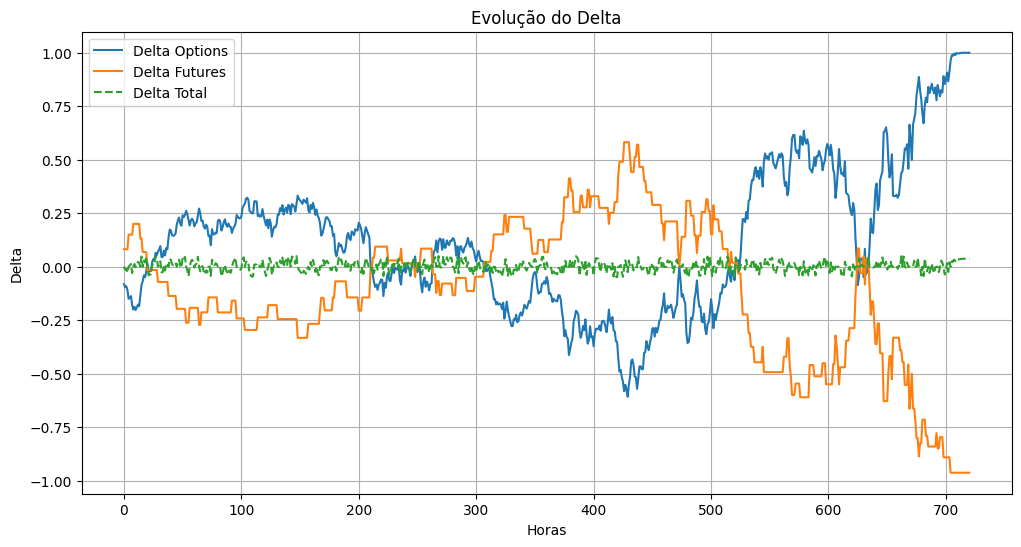

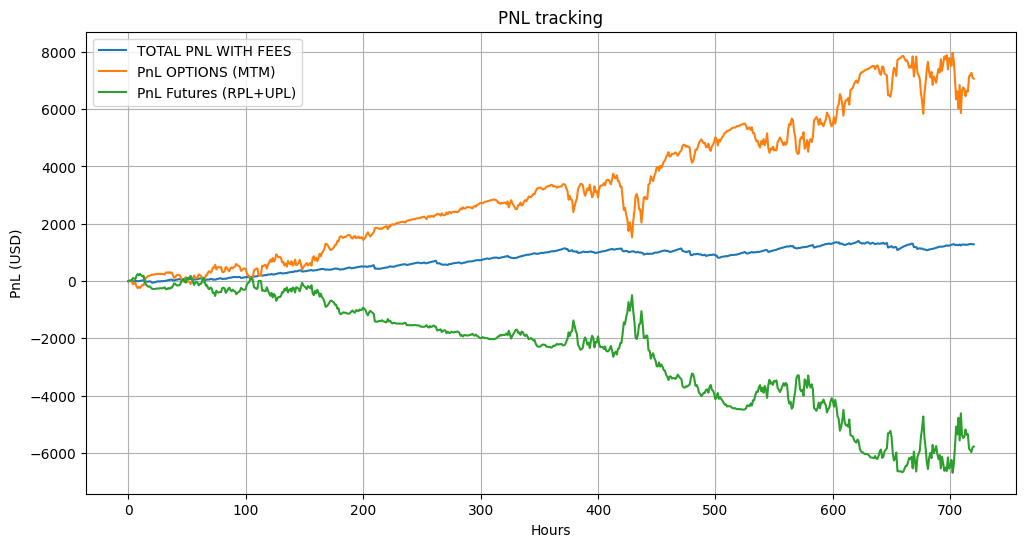

,Hour,BTC_Price,Delta_Options,Delta_Futures,Delta_Total,Put_Price,Call_Price,Option_MTM,RPL_Futures,UPL_Futures,Total_PNL_BeforeOptionFee,Total_PNL
0,0,95000.000000,-0.081716,0.081716,0.000000,5548.649011,5.938259e+03,0.000000,0.00000,0.000000,0.000000,-3.446072
1,1,95247.043918,-0.095167,0.081716,-0.013451,5432.394786,6.068509e+03,-13.995454,0.00000,20.187433,6.191979,2.745907
2,2,95178.098471,-0.091354,0.081716,-0.009638,5459.932145,6.026560e+03,0.415294,0.00000,14.553489,14.968784,11.522711
3,3,95500.834359,-0.108903,0.081716,-0.027188,5311.076366,6.199901e+03,-24.069016,0.00000,40.926165,16.857150,13.411077
4,4,96262.316303,-0.149958,0.149958,0.000000,4976.112325,6.625878e+03,-115.082853,0.00000,103.151401,-11.931452,-15.377524
...,...,...,...,...,...,...,...,...,...,...,...,...
716,716,90653.010427,0.999941,-0.962603,0.037338,4344.824767,4.119427e-03,7142.078977,-6371.18783,520.211405,1291.102552,1287.656480
717,717,90707.222685,0.999980,-0.962603,0.037378,4291.150835,2.184993e-04,7195.756810,-6371.18783,468.026544,1292.595524,1289.149451
718,718,90778.598317,0.999989,-0.962603,0.037386,4220.317215,8.627238e-07,7266.590648,-6371.18783,399.320173,1294.722991,1291.276918
719,719,90605.789475,0.999994,-0.962603,0.037392,4393.668289,1.880866e-15,7093.239575,-6371.18783,565.666418,1287.718163,1284.272090


In [93]:
simulate_short_strangle(
    S0=95000,
    DTE=30,
    iv=0.53,
    vol_real=0.49,
    strike_put=95000,
    strike_call=95000,
    delta_hedge_range=0.05
)